# Pelatihan Model XGBoost, Deteksi Risiko Stroke ANTARAGA

Notebook ini menjalankan ulang, tahap demi tahap, logika yang ada di
`model/train.py`, skrip yang menghasilkan model yang saat ini berjalan
di server produksi.

Semua `random_state = 42`, sama persis dengan skrip aslinya, sehingga
angka yang muncul di sini **identik** dengan `model/artifacts/metrics.json`.

---

## Cara memakai notebook ini untuk logbook

Setiap sel yang perlu difoto diberi penanda seperti ini:

Jalankan `Run All` sekali, lalu screenshot sel-sel bertanda tersebut.

## 0. Persiapan

*Tidak perlu di-screenshot, hanya impor pustaka.*

In [1]:
import json, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_predict, train_test_split,
)
from xgboost import XGBClassifier

warnings.simplefilter("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

ROOT = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
DATA_PATH = ROOT / "healthcare-dataset-stroke-data.csv"

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

NUMERIC_FEATURES     = ["age", "avg_glucose_level", "bmi"]
BINARY_FEATURES      = ["hypertension", "heart_disease", "is_working"]
CATEGORICAL_FEATURES = ["gender", "residence_type", "smoking_status"]
FEATURE_ORDER = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

CATEGORY_VALUES = {
    "gender": ["Male", "Female", "Other"],
    "residence_type": ["Urban", "Rural"],
    "smoking_status": ["formerly smoked", "never smoked", "smokes", "Unknown"],
}
print("Pustaka siap. Dataset:", DATA_PATH.name)

Pustaka siap. Dataset: healthcare-dataset-stroke-data.csv


---
## 1. Muat Dataset & Ketidakseimbangan Kelas

Ini bukti rasio 1:19,56 dan proporsi 4,87% yang Anda tulis di logbook.

In [2]:
def load_dataset() -> pd.DataFrame:
    df = pd.read_csv(DATA_PATH)
    df = df.rename(columns={"Residence_type": "residence_type"})
    # work_type 5 kategori dipadatkan jadi biner, agar cocok dengan input mobile app
    df["is_working"] = df["work_type"].isin(
        ["Private", "Self-employed", "Govt_job"]
    ).astype(int)
    for col, cats in CATEGORY_VALUES.items():
        df[col] = pd.Categorical(df[col], categories=cats)
    return df[FEATURE_ORDER + ["stroke"]]

df = load_dataset()
neg, pos = int((df.stroke == 0).sum()), int((df.stroke == 1).sum())

print(f"Total baris        : {len(df):,}")
print(f"Jumlah fitur       : {len(FEATURE_ORDER)}")
print(f"Nilai kosong (BMI) : {int(df.bmi.isna().sum())}")
print()
print("SEBARAN KELAS")
print(f"  Tidak stroke (0) : {neg:,}  ({100*neg/len(df):.2f}%)")
print(f"  Stroke       (1) : {pos:,}  ({100*pos/len(df):.2f}%)")
print()
print(f"  Rasio ketidakseimbangan = {neg}/{pos} = 1 : {neg/pos:.2f}")
print(f"  -> scale_pos_weight yang dipakai XGBoost = {neg/pos:.4f}")

Total baris        : 5,110
Jumlah fitur       : 9
Nilai kosong (BMI) : 201

SEBARAN KELAS
  Tidak stroke (0) : 4,861  (95.13%)
  Stroke       (1) : 249  (4.87%)

  Rasio ketidakseimbangan = 4861/249 = 1 : 19.52
  -> scale_pos_weight yang dipakai XGBoost = 19.5221


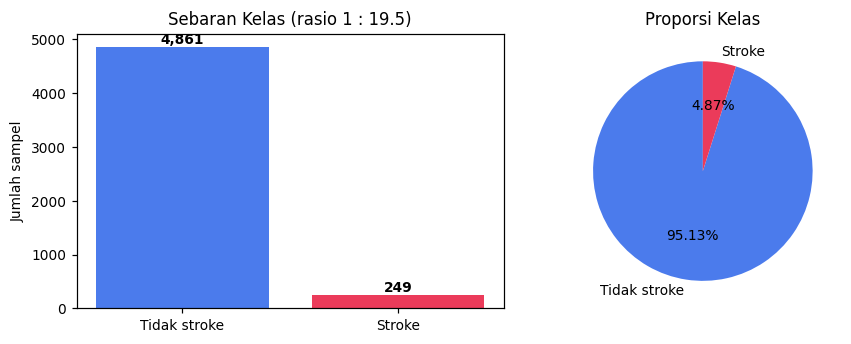

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
ax[0].bar(["Tidak stroke", "Stroke"], [neg, pos], color=["#4b7bec", "#eb3b5a"])
ax[0].set_title(f"Sebaran Kelas (rasio 1 : {neg/pos:.1f})")
ax[0].set_ylabel("Jumlah sampel")
for i, v in enumerate([neg, pos]):
    ax[0].text(i, v + 60, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

ax[1].pie([neg, pos], labels=["Tidak stroke", "Stroke"], autopct="%1.2f%%",
          colors=["#4b7bec", "#eb3b5a"], startangle=90,
          textprops={"fontsize": 9})
ax[1].set_title("Proporsi Kelas")
plt.tight_layout(); plt.show()

---
## 2. Pembagian Data Terstratifikasi

*Opsional di-screenshot.* Stratifikasi menjaga proporsi 4,87% tetap sama
di data latih maupun uji, tanpa ini, data uji bisa kebetulan berisi
terlalu sedikit kasus stroke sehingga evaluasi jadi tidak bermakna.

In [4]:
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Data latih : {len(X_train):,} baris  ({int(y_train.sum())} kasus stroke, {100*y_train.mean():.2f}%)")
print(f"Data uji   : {len(X_test):,} baris  ({int(y_test.sum())} kasus stroke, {100*y_test.mean():.2f}%)")

Data latih : 3,577 baris  (174 kasus stroke, 4.86%)
Data uji   : 1,533 baris  (75 kasus stroke, 4.89%)


---
## 3. Mengapa Akurasi Tidak Dipakai

Diuji dengan model paling sederhana: apa pun datanya, jawabannya selalu
"sehat". Perhatikan akurasi yang dihasilkan.

In [5]:
from sklearn.metrics import accuracy_score

# Model paling malas: apapun datanya, jawab "sehat" terus.
y_malas = np.zeros(len(y_test), dtype=int)

n_sehat  = int((y_test == 0).sum())
n_stroke = int((y_test == 1).sum())

skor = {
    "Akurasi":       accuracy_score(y_test, y_malas),
    "ROC-AUC":       roc_auc_score(y_test, y_malas),
    "Recall":        recall_score(y_test, y_malas, zero_division=0),
    "Presisi":       precision_score(y_test, y_malas, zero_division=0),
    "Avg Precision": average_precision_score(y_test, y_malas),
}

print(f"Data uji: {len(y_test):,} orang ({n_sehat:,} sehat, {n_stroke} kena stroke)")
print()
print('Model ini hanya bisa jawab "sehat". Tidak pernah belajar apa-apa.')
print()
for k, v in skor.items():
    tanda = "  <-- terlihat sangat baik" if k == "Akurasi" else ""
    print(f"  {k:16s}: {v:.4f}{tanda}")
print()
print(f"Akurasinya {100*skor['Akurasi']:.1f}% hanya karena {n_sehat:,} dari {len(y_test):,} orang")
print("di data uji memang sehat. Menjawab 'sehat' terus-menerus otomatis benar sebanyak itu.")
print()
print(f"Tapi dari {n_stroke} orang yang benar-benar kena stroke, tidak ada satupun ketemu.")
print("ROC-AUC 0,5 artinya sama saja setara tebak acak. Recall dan presisinya nol.")
print()
print("Karena itu akurasi tidak dipakai. Metrik utama ganti ke Average Precision,")
print("didampingi ROC-AUC, recall, dan presisi.")

Data uji: 1,533 orang (1,458 sehat, 75 kena stroke)

Model ini hanya bisa jawab "sehat". Tidak pernah belajar apa-apa.

  Akurasi         : 0.9511  <-- terlihat sangat baik
  ROC-AUC         : 0.5000
  Recall          : 0.0000
  Presisi         : 0.0000
  Avg Precision   : 0.0489

Akurasinya 95.1% hanya karena 1,458 dari 1,533 orang
di data uji memang sehat. Menjawab 'sehat' terus-menerus otomatis benar sebanyak itu.

Tapi dari 75 orang yang benar-benar kena stroke, tidak ada satupun ketemu.
ROC-AUC 0,5 artinya sama saja setara tebak acak. Recall dan presisinya nol.

Karena itu akurasi tidak dipakai. Metrik utama ganti ke Average Precision,
didampingi ROC-AUC, recall, dan presisi.


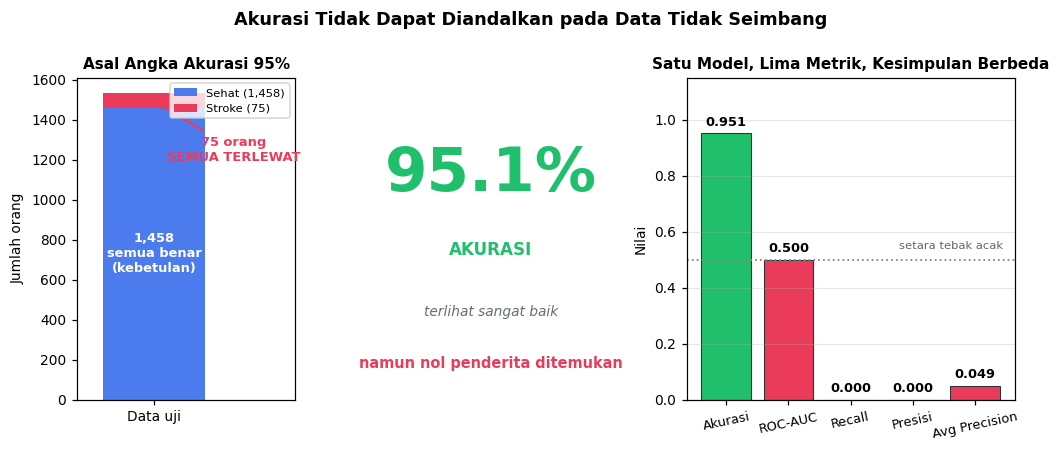

In [6]:
fig = plt.figure(figsize=(11, 3.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.85, 1.5], wspace=0.42)

# Kiri: dari mana angka 95% itu datang
a0 = fig.add_subplot(gs[0])
a0.bar(["Data uji"], [n_sehat], color="#4b7bec", label=f"Sehat ({n_sehat:,})")
a0.bar(["Data uji"], [n_stroke], bottom=[n_sehat], color="#eb3b5a",
       label=f"Stroke ({n_stroke})")
a0.text(0, n_sehat/2, f"{n_sehat:,}\nsemua benar\n(kebetulan)", ha="center",
        va="center", color="white", fontsize=8.5, fontweight="bold")
a0.annotate(f"{n_stroke} orang\nSEMUA TERLEWAT", xy=(0, n_sehat + n_stroke/2),
            xytext=(0.62, n_sehat*0.82), fontsize=8.5, color="#eb3b5a",
            fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color="#eb3b5a", lw=1.4))
a0.set_ylabel("Jumlah orang")
a0.set_title("Asal Angka Akurasi 95%", fontsize=10, fontweight="bold")
a0.legend(fontsize=7.5, loc="upper right")
a0.set_xlim(-0.6, 1.1)

# Tengah: angka akurasi besar
a1 = fig.add_subplot(gs[1]); a1.axis("off")
a1.text(.5, .70, f"{100*skor['Akurasi']:.1f}%", ha="center", va="center",
        fontsize=40, fontweight="bold", color="#20bf6b")
a1.text(.5, .45, "AKURASI", ha="center", fontsize=11, color="#20bf6b",
        fontweight="bold")
a1.text(.5, .26, "terlihat sangat baik", ha="center", fontsize=9,
        style="italic", color="#636e72")
a1.text(.5, .10, "namun nol penderita ditemukan", ha="center", fontsize=9.5,
        color="#eb3b5a", fontweight="bold")

# Kanan: metrik pendukung
a2 = fig.add_subplot(gs[2])
nama = list(skor.keys()); nilai = list(skor.values())
warna = ["#20bf6b"] + ["#eb3b5a"]*4
b = a2.bar(nama, nilai, color=warna, edgecolor="#2d3436", linewidth=.7)
a2.bar_label(b, fmt="%.3f", fontsize=8.5, fontweight="bold", padding=3)
a2.axhline(0.5, color="#888", ls=":", lw=1.2)
a2.text(4.45, 0.54, "setara tebak acak", fontsize=7.5, color="#666", ha="right")
a2.set_ylim(0, 1.15); a2.set_ylabel("Nilai")
a2.set_title("Satu Model, Lima Metrik, Kesimpulan Berbeda",
             fontsize=10, fontweight="bold")
a2.tick_params(axis="x", labelsize=8.5, rotation=12)
a2.grid(axis="y", alpha=.3)

fig.suptitle("Akurasi Tidak Dapat Diandalkan pada Data Tidak Seimbang",
             fontsize=11.5, fontweight="bold", y=1.04)
plt.show()

---
## 4. Dua Kandidat dengan Pembobotan Kelas

Perhatikan dua cara pembobotan: `class_weight="balanced"` pada
HistGradientBoosting, dan `scale_pos_weight` pada XGBoost.

In [7]:
def tune_hist_gb(X, y):
    """Pembobotan lewat class_weight='balanced': bawaan scikit-learn."""
    param_distributions = {
        "max_iter": [100, 150, 200, 300],
        "max_depth": [3, 4, 5, 6, None],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "max_leaf_nodes": [15, 31, 63],
        "l2_regularization": [0.0, 0.1, 0.5, 1.0],
        "min_samples_leaf": [10, 20, 30],
    }
    search = RandomizedSearchCV(
        estimator=HistGradientBoostingClassifier(
            categorical_features="from_dtype",
            class_weight="balanced",          # <-- pembobotan kelas
            random_state=RANDOM_STATE,
        ),
        param_distributions=param_distributions,
        n_iter=40, scoring="average_precision", cv=CV,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X, y)
    return search


def _ordinal_encode_for_xgb(X):
    X = X.copy()
    for col in CATEGORICAL_FEATURES:
        X[col] = X[col].cat.codes.astype("float64").replace(-1, np.nan)
    return X


def tune_xgb(X, y):
    """Pembobotan lewat scale_pos_weight: hiperparameter model, bukan
    array bobot saat fit, sehingga tidak mungkin bocor ke penilai (scorer)."""
    X_enc = _ordinal_encode_for_xgb(X)
    base_ratio = (y == 0).sum() / (y == 1).sum()
    param_distributions = {
        "n_estimators": [100, 150, 200, 300],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "min_child_weight": [1, 5, 10],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.5, 1.0, 2.0],
        # 1.0 = tanpa pembobotan; base_ratio = pembobotan penuh (19,56)
        "scale_pos_weight": [1.0, base_ratio*0.25, base_ratio*0.5, base_ratio],
    }
    search = RandomizedSearchCV(
        estimator=XGBClassifier(
            tree_method="hist", eval_metric="aucpr", random_state=RANDOM_STATE,
        ),
        param_distributions=param_distributions,
        n_iter=40, scoring="average_precision", cv=CV,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_enc, y)
    return search

print("Dua fungsi penyetelan siap.")
print("Keduanya dinilai dengan metrik yang sama (average_precision)")
print("dan skema validasi yang sama (StratifiedKFold 5-lipat) agar adil.")

Dua fungsi penyetelan siap.
Keduanya dinilai dengan metrik yang sama (average_precision)
dan skema validasi yang sama (StratifiedKFold 5-lipat) agar adil.


Membuktikan efek pembobotan: dua XGBoost dengan parameter identik,
yang membedakan hanya `scale_pos_weight`.

In [8]:
# Kategori diubah jadi kode angka supaya XGBoost bisa memprosesnya
Xtr_e = X_train.copy(); Xte_e = X_test.copy()
for c in CATEGORICAL_FEATURES:
    Xtr_e[c] = Xtr_e[c].cat.codes.astype("float64").replace(-1, np.nan)
    Xte_e[c] = Xte_e[c].cat.codes.astype("float64").replace(-1, np.nan)

rasio = (y_train == 0).sum() / (y_train == 1).sum()
dasar = dict(tree_method="hist", eval_metric="aucpr", random_state=RANDOM_STATE,
             n_estimators=100, max_depth=4, learning_rate=0.03, min_child_weight=5)

banding = {}
for label, spw in [("Tanpa pembobotan\n(scale_pos_weight=1)", 1.0),
                   (f"Dengan pembobotan\n(scale_pos_weight={rasio:.2f})", rasio)]:
    mm = XGBClassifier(**dasar, scale_pos_weight=spw).fit(Xtr_e, y_train)
    yp = (mm.predict_proba(Xte_e)[:, 1] >= 0.5).astype(int)
    banding[label] = {
        "Recall":  recall_score(y_test, yp, zero_division=0),
        "Presisi": precision_score(y_test, yp, zero_division=0),
        "F1":      f1_score(y_test, yp, zero_division=0),
        "_tp": int(((yp == 1) & (y_test == 1)).sum()),
    }

total_pos = int(y_test.sum())
for lab, m in banding.items():
    print(lab.replace(chr(10), " "))
    print(f"    Recall  : {m['Recall']:.4f}")
    print(f"    Presisi : {m['Presisi']:.4f}")
    print(f"    F1      : {m['F1']:.4f}")
    print(f"    Penderita terdeteksi: {m['_tp']} dari {total_pos}")
    print()
print("Pembobotan menaikkan recall secara drastis")
print("mengabaikan kelas minoritas, dengan konsekuensi presisi menurun.")

Tanpa pembobotan (scale_pos_weight=1)
    Recall  : 0.0133
    Presisi : 1.0000
    F1      : 0.0263
    Penderita terdeteksi: 1 dari 75

Dengan pembobotan (scale_pos_weight=19.56)
    Recall  : 0.7600
    Presisi : 0.1226
    F1      : 0.2111
    Penderita terdeteksi: 57 dari 75

Pembobotan menaikkan recall secara drastis
mengabaikan kelas minoritas, dengan konsekuensi presisi menurun.


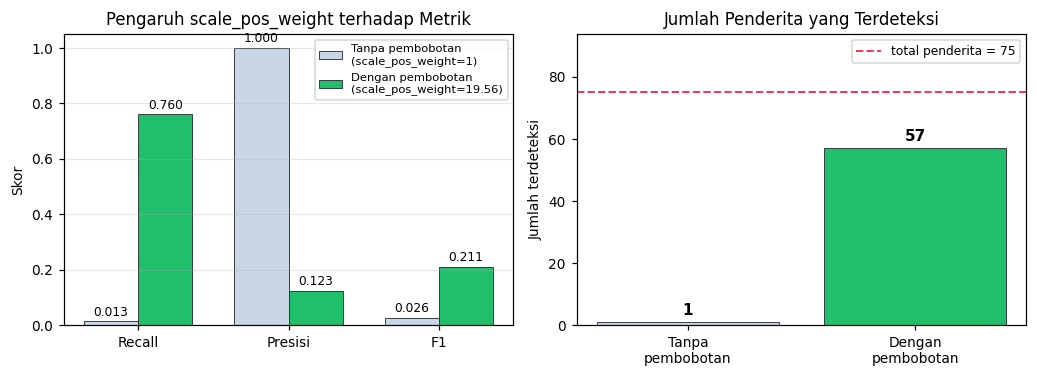

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.5))
metrik = ["Recall", "Presisi", "F1"]
labs = list(banding.keys()); xp = np.arange(len(metrik)); w = 0.36

for i, (n, col) in enumerate(zip(labs, ["#c8d6e5", "#20bf6b"])):
    b = ax[0].bar(xp + (i - .5) * w, [banding[n][m] for m in metrik], w,
                  label=n, color=col, edgecolor="#2d3436", linewidth=.6)
    ax[0].bar_label(b, fmt="%.3f", fontsize=8, padding=2)
ax[0].set_xticks(xp, metrik); ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("Skor")
ax[0].set_title("Pengaruh scale_pos_weight terhadap Metrik")
ax[0].legend(fontsize=7.5); ax[0].grid(axis="y", alpha=.3)

tps = [banding[n]["_tp"] for n in labs]
b2 = ax[1].bar(["Tanpa\npembobotan", "Dengan\npembobotan"], tps,
               color=["#c8d6e5", "#20bf6b"], edgecolor="#2d3436", linewidth=.6)
ax[1].bar_label(b2, fmt="%d", fontsize=10, fontweight="bold", padding=3)
ax[1].axhline(total_pos, color="#eb3b5a", ls="--", lw=1.3,
              label=f"total penderita = {total_pos}")
ax[1].set_ylim(0, total_pos * 1.25); ax[1].set_ylabel("Jumlah terdeteksi")
ax[1].set_title("Jumlah Penderita yang Terdeteksi")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 5. Penyetelan Hiperparameter

RandomizedSearchCV mencoba 40 kombinasi, tiap kombinasi diuji 5 lipatan.
Jadi total 200 pelatihan per model.
Sel ini perlu waktu beberapa menit.

In [10]:
import time

print("Menyetel HistGradientBoostingClassifier ...")
t0 = time.time()
hgb_search = tune_hist_gb(X_train, y_train)
print(f"  selesai dalam {time.time()-t0:.1f} detik")
print(f"  average precision (CV) = {hgb_search.best_score_:.4f}")
print()

print("Menyetel XGBClassifier ...")
t0 = time.time()
xgb_search = tune_xgb(X_train, y_train)
print(f"  selesai dalam {time.time()-t0:.1f} detik")
print(f"  average precision (CV) = {xgb_search.best_score_:.4f}")

Menyetel HistGradientBoostingClassifier ...


  selesai dalam 5.0 detik
  average precision (CV) = 0.2281

Menyetel XGBClassifier ...


  selesai dalam 1.0 detik
  average precision (CV) = 0.2313


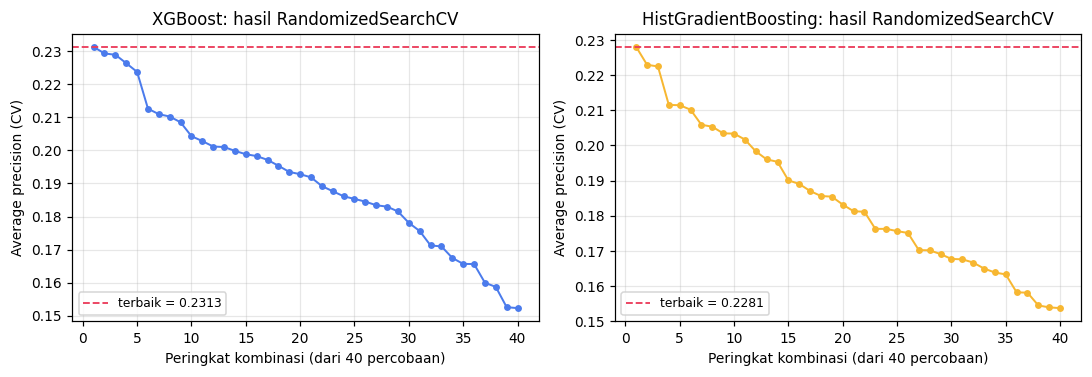

Tiap model: 40 kombinasi x 5 lipatan = 200 pelatihan.
Selisih kombinasi terbaik dan terburuk XGBoost: 0.0790


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

for a, srch, judul, col in [
    (ax[0], xgb_search, "XGBoost", "#4b7bec"),
    (ax[1], hgb_search, "HistGradientBoosting", "#f7b731"),
]:
    sk = np.sort(srch.cv_results_["mean_test_score"])[::-1]
    a.plot(range(1, len(sk) + 1), sk, "o-", ms=3.5, lw=1.3, color=col)
    a.axhline(srch.best_score_, ls="--", lw=1.2, color="#eb3b5a",
              label=f"terbaik = {srch.best_score_:.4f}")
    a.set_xlabel("Peringkat kombinasi (dari 40 percobaan)")
    a.set_ylabel("Average precision (CV)")
    a.set_title(f"{judul}: hasil RandomizedSearchCV")
    a.legend(fontsize=8); a.grid(alpha=.3)

plt.tight_layout(); plt.show()
print(f"Tiap model: 40 kombinasi x 5 lipatan = 200 pelatihan.")
print(f"Selisih kombinasi terbaik dan terburuk XGBoost: "
      f"{xgb_search.cv_results_['mean_test_score'].max() - xgb_search.cv_results_['mean_test_score'].min():.4f}")

---
## 6. Pemilihan Model

In [12]:
if hgb_search.best_score_ >= xgb_search.best_score_:
    model_name, search, encoding = "HistGradientBoostingClassifier", hgb_search, "native_categorical"
    X_train_model, X_test_model = X_train, X_test
else:
    model_name, search, encoding = "XGBClassifier", xgb_search, "ordinal_codes"
    X_train_model = _ordinal_encode_for_xgb(X_train)
    X_test_model  = _ordinal_encode_for_xgb(X_test)

model = search.best_estimator_

print("PERBANDINGAN (average precision, validasi silang 5-lipat)")
print(f"  HistGradientBoosting : {hgb_search.best_score_:.4f}")
print(f"  XGBoost              : {xgb_search.best_score_:.4f}")
print()
print(f"MODEL TERPILIH: {model_name}")
print(f"  selisih: {abs(xgb_search.best_score_-hgb_search.best_score_):.4f}")
print()
print("HIPERPARAMETER TERBAIK")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:20s} = {v}")

PERBANDINGAN (average precision, validasi silang 5-lipat)
  HistGradientBoosting : 0.2281
  XGBoost              : 0.2313

MODEL TERPILIH: XGBClassifier
  selisih: 0.0032

HIPERPARAMETER TERBAIK
  colsample_bytree     = 1.0
  learning_rate        = 0.03
  max_depth            = 4
  min_child_weight     = 5
  n_estimators         = 100
  reg_lambda           = 1.0
  scale_pos_weight     = 19.557471264367816
  subsample            = 1.0


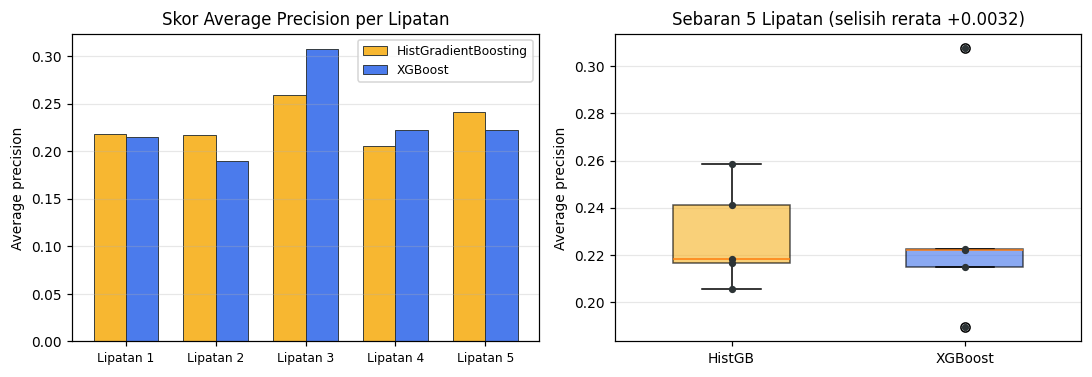

HistGradientBoosting : rerata 0.2281  (sd 0.0192)
XGBoost              : rerata 0.2313  (sd 0.0402)



In [13]:
def skor_lipatan(srch):
    i = srch.best_index_
    return [srch.cv_results_[f"split{k}_test_score"][i] for k in range(5)]

s_hgb, s_xgb = skor_lipatan(hgb_search), skor_lipatan(xgb_search)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
xp = np.arange(5); w = 0.36
b1 = ax[0].bar(xp - w/2, s_hgb, w, label="HistGradientBoosting", color="#f7b731",
               edgecolor="#2d3436", linewidth=.6)
b2 = ax[0].bar(xp + w/2, s_xgb, w, label="XGBoost", color="#4b7bec",
               edgecolor="#2d3436", linewidth=.6)
ax[0].set_xticks(xp, [f"Lipatan {i+1}" for i in range(5)], fontsize=8)
ax[0].set_ylabel("Average precision"); ax[0].set_title("Skor Average Precision per Lipatan")
ax[0].legend(fontsize=8); ax[0].grid(axis="y", alpha=.3)

bp = ax[1].boxplot([s_hgb, s_xgb], labels=["HistGB", "XGBoost"],
                   patch_artist=True, widths=.5)
for patch, col in zip(bp["boxes"], ["#f7b731", "#4b7bec"]):
    patch.set_facecolor(col); patch.set_alpha(.65)
for i, s in enumerate([s_hgb, s_xgb], start=1):
    ax[1].scatter([i]*5, s, color="#2d3436", s=14, zorder=3)
ax[1].set_ylabel("Average precision")
ax[1].set_title(f"Sebaran 5 Lipatan (selisih rerata {xgb_search.best_score_-hgb_search.best_score_:+.4f})")
ax[1].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(f"HistGradientBoosting : rerata {np.mean(s_hgb):.4f}  (sd {np.std(s_hgb):.4f})")
print(f"XGBoost              : rerata {np.mean(s_xgb):.4f}  (sd {np.std(s_xgb):.4f})")
print()

---
## 7. Menentukan Ambang Keputusan

Ambang bawaan 0,5 tidak cocok di sini. Recall didahulukan, karena melewatkan
penderita berakibat jauh lebih serius daripada salah menandai orang sehat.
Ambang dicari dari prediksi **out-of-fold pada data latih**, bukan dari data
uji. Memakai data uji membuat ambang ikut menyesuaikan jawaban, sehingga hasil
evaluasinya tampak lebih baik daripada kenyataan.

In [14]:
TARGET_RECALL = 0.98

def best_f1_threshold(y_true, y_proba):
    """Ambang dengan keseimbangan terbaik antara presisi dan recall."""
    cand = np.linspace(0.05, 0.95, 181)
    sc = [f1_score(y_true, (y_proba >= t).astype(int)) for t in cand]
    return float(cand[int(np.argmax(sc))]), cand, sc

def recall_target_threshold(y_true, y_proba, target=TARGET_RECALL):
    """Ambang TERTINGGI yang recall-nya masih >= target.

    Diambil yang tertinggi karena tiap penurunan ambang menambah salah tandai.
    Begitu target tercapai, menurunkannya lagi hanya menambah salah tandai.
    """
    for t in np.linspace(0.99, 0.01, 981):
        if recall_score(y_true, (y_proba >= t).astype(int), zero_division=0) >= target:
            return float(t)
    return 0.01

oof_proba = cross_val_predict(model, X_train_model, y_train, cv=CV,
                              method="predict_proba")[:, 1]
yt = y_train.to_numpy()

th_f1, cand, f1s = best_f1_threshold(yt, oof_proba)
th_deteksi = recall_target_threshold(yt, oof_proba, TARGET_RECALL)

print("DUA AMBANG DENGAN FUNGSI BERBEDA")
print()
print(f"  Ambang deteksi        : {th_deteksi:.3f}")
print(f"    Menentukan siapa yang perlu pemeriksaan lanjutan.")
print(f"    Sengaja dipasang rendah agar hampir tidak ada penderita yang terlewat.")
print()
print(f"  Ambang 'risiko tinggi': {th_f1:.3f}")
print(f"    Menentukan label yang tampil di aplikasi. Memakai titik F1 terbaik,")
print(f"    tempat presisi dan recall paling seimbang.")
print()
print("Alasan target recall dipatok 0,98, bukan 1,0:")
print("  Recall sempurna baru tercapai bila ambang turun ke sekitar 0,02.")
print("  Pada titik itu model menandai seluruh orang, termasuk yang sehat.")
print("  Presisinya turun ke proporsi penderita di populasi,")
print("  sehingga keluarannya tidak lagi membawa informasi.")
print()
print("Alasan memakai 0,98 pada OOF, bukan 0,93:")
print("  Ambang dari data latih selalu melemah saat dipakai di data baru.")
print("  Target OOF 0,93 hanya menghasilkan recall 0,84 di data uji, sedangkan 0,98")
print("  menghasilkan 0,97. Jadi angkanya diberi margin, bukan disesuaikan dengan hasil uji.")

threshold = th_deteksi
high_threshold = th_f1

DUA AMBANG DENGAN FUNGSI BERBEDA

  Ambang deteksi        : 0.042
    Menentukan siapa yang perlu pemeriksaan lanjutan.
    Sengaja dipasang rendah agar hampir tidak ada penderita yang terlewat.

  Ambang 'risiko tinggi': 0.705
    Menentukan label yang tampil di aplikasi. Memakai titik F1 terbaik,
    tempat presisi dan recall paling seimbang.

Alasan target recall dipatok 0,98, bukan 1,0:
  Recall sempurna baru tercapai bila ambang turun ke sekitar 0,02.
  Pada titik itu model menandai seluruh orang, termasuk yang sehat.
  Presisinya turun ke proporsi penderita di populasi,
  sehingga keluarannya tidak lagi membawa informasi.

Alasan memakai 0,98 pada OOF, bukan 0,93:
  Ambang dari data latih selalu melemah saat dipakai di data baru.
  Target OOF 0,93 hanya menghasilkan recall 0,84 di data uji, sedangkan 0,98
  menghasilkan 0,97. Jadi angkanya diberi margin, bukan disesuaikan dengan hasil uji.


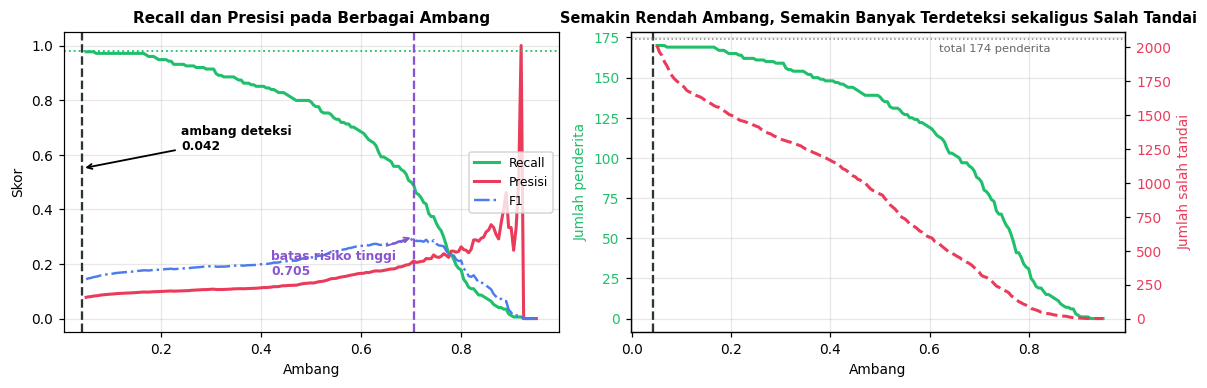

In [15]:
recalls = [recall_score(yt, (oof_proba >= t).astype(int), zero_division=0) for t in cand]
precs   = [precision_score(yt, (oof_proba >= t).astype(int), zero_division=0) for t in cand]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(cand, recalls, lw=2, color="#20bf6b", label="Recall")
ax[0].plot(cand, precs,   lw=2, color="#eb3b5a", label="Presisi")
ax[0].plot(cand, f1s,     lw=1.6, color="#4b7bec", ls="-.", label="F1")
ax[0].axhline(TARGET_RECALL, color="#20bf6b", ls=":", lw=1.2)
ax[0].axvline(th_deteksi, color="#2d3436", ls="--", lw=1.5)
ax[0].axvline(th_f1, color="#8854d0", ls="--", lw=1.5)
ax[0].annotate(f"ambang deteksi\n{th_deteksi:.3f}", xy=(th_deteksi, 0.55),
               xytext=(0.24, 0.62), fontsize=8, fontweight="bold",
               arrowprops=dict(arrowstyle="->", lw=1.2))
ax[0].annotate(f"batas risiko tinggi\n{th_f1:.3f}", xy=(th_f1, 0.30),
               xytext=(0.42, 0.16), fontsize=8, fontweight="bold", color="#8854d0",
               arrowprops=dict(arrowstyle="->", lw=1.2, color="#8854d0"))
ax[0].set_xlabel("Ambang"); ax[0].set_ylabel("Skor")
ax[0].set_title("Recall dan Presisi pada Berbagai Ambang", fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8, loc="center right"); ax[0].grid(alpha=.3)

# Berapa penderita terdeteksi kalau ambangnya digeser
tot_tr = int(yt.sum())
tps = [int(((oof_proba >= t) & (yt == 1)).sum()) for t in cand]
fps = [int(((oof_proba >= t) & (yt == 0)).sum()) for t in cand]
ax[1].plot(cand, tps, lw=2, color="#20bf6b", label="Penderita terdeteksi")
ax[1].axvline(th_deteksi, color="#2d3436", ls="--", lw=1.5)
ax[1].axhline(tot_tr, color="#888", ls=":", lw=1)
ax[1].text(0.62, tot_tr*0.955, f"total {tot_tr} penderita", fontsize=7.5, color="#666")
ax[1].set_xlabel("Ambang"); ax[1].set_ylabel("Jumlah penderita", color="#20bf6b")
ax[1].tick_params(axis="y", labelcolor="#20bf6b")
a2 = ax[1].twinx()
a2.plot(cand, fps, lw=2, color="#eb3b5a", ls="--", label="Salah tandai")
a2.set_ylabel("Jumlah salah tandai", color="#eb3b5a")
a2.tick_params(axis="y", labelcolor="#eb3b5a")
ax[1].set_title("Semakin Rendah Ambang, Semakin Banyak Terdeteksi sekaligus Salah Tandai",
                fontsize=9.5, fontweight="bold")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 8. Evaluasi di Data Uji

Data uji ini belum pernah dilihat model, baik waktu latihan maupun waktu
nentuin ambang.

In [16]:
proba_test = model.predict_proba(X_test_model)[:, 1]
y_pred = (proba_test >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tot = tp + fn

print(f"Data uji: {len(y_test):,} orang, {tot} di antaranya kena stroke")
print()
print("METRIK")
print(f"  ROC-AUC           : {roc_auc_score(y_test, proba_test):.4f}")
print(f"  Average precision : {average_precision_score(y_test, proba_test):.4f}")
print(f"  Recall            : {recall_score(y_test, y_pred):.4f}   <-- prioritas utama")
print(f"  Presisi           : {precision_score(y_test, y_pred):.4f}")
print(f"  F1                : {f1_score(y_test, y_pred):.4f}")
print()
print("MATRIKS KONFUSI")
print(f"  Sehat, ditandai sehat     (TN) : {tn:5d}")
print(f"  Sehat, ditandai berisiko  (FP) : {fp:5d}")
print(f"  Stroke, TERLEWAT          (FN) : {fn:5d}")
print(f"  Stroke, terdeteksi         (TP) : {tp:5d}")
print()
print(f"Dari {tot} penderita, {tp} terdeteksi ({100*tp/tot:.1f}%). Hanya {fn} yang lolos.")
print()
print("Konsekuensinya:")
print(f"  {fp:,} dari {tn+fp:,} orang sehat ikut ketandai ({100*fp/(tn+fp):.0f}%).")
print(f"  Presisi {precision_score(y_test, y_pred):.3f} artinya dari 100 orang yang ditandai,")
print(f"  sekitar {100*precision_score(y_test, y_pred):.0f} benar-benar berisiko.")
print()
print("Untuk alat skrining, rasio ini masih dapat diterima. Yang ditandai bukan divonis")
print("stroke, hanya diminta periksa lebih lanjut.")

Data uji: 1,533 orang, 75 di antaranya kena stroke

METRIK
  ROC-AUC           : 0.8230
  Average precision : 0.2500
  Recall            : 0.9733   <-- prioritas utama
  Presisi           : 0.0746
  F1                : 0.1387

MATRIKS KONFUSI
  Sehat, ditandai sehat     (TN) :   553
  Sehat, ditandai berisiko  (FP) :   905
  Stroke, TERLEWAT          (FN) :     2
  Stroke, terdeteksi         (TP) :    73

Dari 75 penderita, 73 terdeteksi (97.3%). Hanya 2 yang lolos.

Konsekuensinya:
  905 dari 1,458 orang sehat ikut ketandai (62%).
  Presisi 0.075 artinya dari 100 orang yang ditandai,
  sekitar 7 benar-benar berisiko.

Untuk alat skrining, rasio ini masih dapat diterima. Yang ditandai bukan divonis
stroke, hanya diminta periksa lebih lanjut.


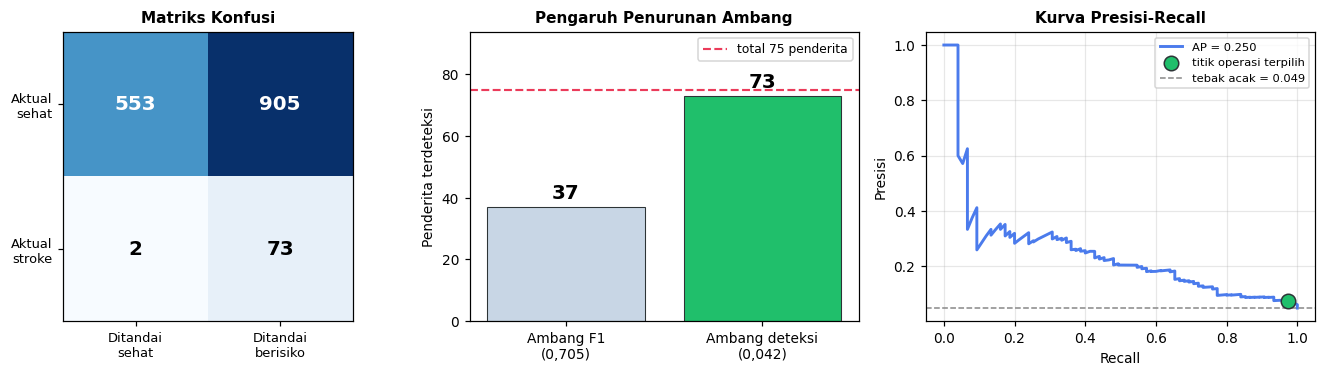

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.5))

im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1], ["Ditandai\nsehat", "Ditandai\nberisiko"], fontsize=8.5)
ax[0].set_yticks([0, 1], ["Aktual\nsehat", "Aktual\nstroke"], fontsize=8.5)
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=13,
                   fontweight="bold",
                   color="white" if cm[i, j] > cm.max()/2 else "black")
ax[0].set_title("Matriks Konfusi", fontsize=10, fontweight="bold")

# Berapa penderita terdeteksi: sebelum vs sesudah
b = ax[1].bar(["Ambang F1\n(0,705)", "Ambang deteksi\n(0,042)"], [37, tp],
              color=["#c8d6e5", "#20bf6b"], edgecolor="#2d3436", linewidth=.7)
ax[1].bar_label(b, fmt="%d", fontsize=13, fontweight="bold", padding=3)
ax[1].axhline(tot, color="#eb3b5a", ls="--", lw=1.4, label=f"total {tot} penderita")
ax[1].set_ylim(0, tot*1.25); ax[1].set_ylabel("Penderita terdeteksi")
ax[1].set_title("Pengaruh Penurunan Ambang", fontsize=10, fontweight="bold")
ax[1].legend(fontsize=8)

pr, rc, _ = precision_recall_curve(y_test, proba_test)
ax[2].plot(rc, pr, color="#4b7bec", lw=1.9,
           label=f"AP = {average_precision_score(y_test, proba_test):.3f}")
ax[2].scatter([recall_score(y_test, y_pred)], [precision_score(y_test, y_pred)],
              s=90, color="#20bf6b", zorder=5, edgecolor="#2d3436",
              label="titik operasi terpilih")
ax[2].axhline(y_test.mean(), color="#888", ls="--", lw=1,
              label=f"tebak acak = {y_test.mean():.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Presisi")
ax[2].set_title("Kurva Presisi-Recall", fontsize=10, fontweight="bold")
ax[2].legend(fontsize=7.5); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

### Presisi 0,075: konsekuensi yang disengaja

Ambang deteksi diturunkan ke 0,042 supaya recall setinggi mungkin. Akibatnya
905 dari 1.458 orang sehat ikut tertandai, dan presisi turun ke 0,075.

Dasar pertimbangannya: ANTARAGA adalah alat skrining awal, bukan alat diagnosis.
Orang yang tertandai tidak divonis stroke, hanya diminta memeriksakan diri lebih
lanjut. Biaya salah tandai adalah satu kali pemeriksaan tambahan, sedangkan biaya
melewatkan penderita jauh lebih besar.

Pembandingnya jelas. Pada ambang F1 terbaik (0,705), presisi naik ke 0,206 tetapi
hanya 37 dari 75 penderita yang terdeteksi. Artinya 38 orang berisiko pulang tanpa
peringatan apa pun.

Recall tidak dipaksa sampai 1,0 karena dua penderita terakhir menuntut ambang
turun ke sekitar 0,02. Pada titik itu seluruh orang sehat ikut tertandai dan
presisi jatuh ke 0,049, persis proporsi penderita di populasi. Keluaran model
tidak lagi membawa informasi.

---
## 9. Recall sebagai Metrik Utama

Pada diagnosis medis, **recall** (disebut juga *sensitivity*) menjawab satu
pertanyaan: dari semua orang yang benar-benar sakit, berapa persen yang berhasil
ditemukan model?

```
                 penderita yang terdeteksi
Recall  =  ----------------------------------------
           seluruh penderita yang ada di data
```

Metrik ini berbeda sifat dengan akurasi, dan perbedaannya menentukan.

**Akurasi menyembunyikan kesalahan yang paling mahal.** Pada penyakit yang jarang,
mayoritas data adalah orang sehat. Model yang selalu menjawab "sehat" otomatis
benar untuk mayoritas itu, sehingga akurasinya tinggi meski tidak satu pun
penderita ditemukan. Angka besar itu memberi rasa aman yang keliru bagi tenaga
medis maupun pasien.

**Recall tidak bisa ditipu dengan cara itu.** Penyebutnya hanya menghitung
penderita, jadi orang sehat tidak ikut menaikkan nilainya. Model yang tidak
menemukan siapa pun akan mendapat recall nol, sebesar apa pun akurasinya.

**Konsekuensi kesalahan tidak simetris.** *False negative* berarti penderita
pulang tanpa peringatan dan tanpa penanganan. *False positive* berarti orang
sehat menjalani satu pemeriksaan tambahan. Karena bobot risikonya jauh berbeda,
recall didahulukan meski presisi harus dikorbankan.

In [18]:
tot   = int(y_test.sum())
tp    = int(((proba_test >= threshold) & (y_test == 1)).sum())
fn    = tot - tp
rec   = tp / tot

# Acuan umum tingkat sensitivitas untuk alat skrining
BAND = [(0.00, 0.70, "Rendah",       "#eb3b5a"),
        (0.70, 0.85, "Sedang",       "#fa8231"),
        (0.85, 0.95, "Baik",         "#f7b731"),
        (0.95, 1.01, "Sangat baik",  "#20bf6b")]
label, warna = next((l, w) for lo, hi, l, w in BAND if lo <= rec < hi)

print("RECALL MODEL ANTARAGA")
print()
print(f"  Penderita di data uji     : {tot}")
print(f"  Berhasil terdeteksi       : {tp}")
print(f"  Terlewat (false negative) : {fn}")
print()
print(f"  Recall = {tp}/{tot} = {rec:.4f}  ({100*rec:.1f}%)")
print(f"  Kategori: {label.upper()}")
print()
print("Acuan umum sensitivitas alat skrining:")
for lo, hi, l, _ in BAND:
    tanda = "  <-- posisi model ini" if l == label else ""
    batas = f"{lo:.2f} sampai {min(hi,1.0):.2f}"
    print(f"  {batas:16s} {l}{tanda}")
print()
print(f"Dengan recall {100*rec:.1f}%, dari setiap 100 penderita yang memakai alat ini")
print(f"sekitar {round(100*rec)} akan mendapat peringatan untuk memeriksakan diri.")
print(f"Sisanya sekitar {round(100*(1-rec))} orang tidak terdeteksi.")
print()
print("Sebagai pembanding, pada ambang F1 terbaik (0,705) recall hanya 0,493.")
print("Artinya lebih dari separuh penderita pulang tanpa peringatan apa pun.")

RECALL MODEL ANTARAGA

  Penderita di data uji     : 75
  Berhasil terdeteksi       : 73
  Terlewat (false negative) : 2

  Recall = 73/75 = 0.9733  (97.3%)
  Kategori: SANGAT BAIK

Acuan umum sensitivitas alat skrining:
  0.00 sampai 0.70 Rendah
  0.70 sampai 0.85 Sedang
  0.85 sampai 0.95 Baik
  0.95 sampai 1.00 Sangat baik  <-- posisi model ini

Dengan recall 97.3%, dari setiap 100 penderita yang memakai alat ini
sekitar 97 akan mendapat peringatan untuk memeriksakan diri.
Sisanya sekitar 3 orang tidak terdeteksi.

Sebagai pembanding, pada ambang F1 terbaik (0,705) recall hanya 0,493.
Artinya lebih dari separuh penderita pulang tanpa peringatan apa pun.


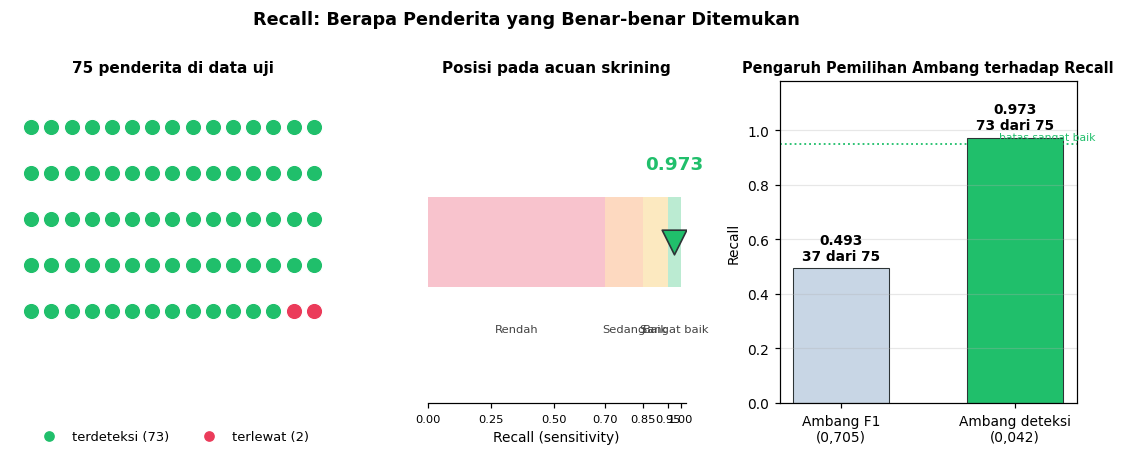

In [19]:
fig = plt.figure(figsize=(12.5, 3.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1, 1.15], wspace=0.32)

# Kiri: 75 penderita digambar satu per satu
a0 = fig.add_subplot(gs[0])
kol = 15
for i in range(tot):
    r, c_ = divmod(i, kol)
    a0.scatter(c_, -r, s=115, marker="o",
               color="#20bf6b" if i < tp else "#eb3b5a",
               edgecolor="white", linewidth=.8)
a0.set_xlim(-1, kol); a0.set_ylim(-(tot//kol) - 1, 1); a0.axis("off")
a0.set_title(f"{tot} penderita di data uji", fontsize=10, fontweight="bold")
a0.scatter([], [], color="#20bf6b", label=f"terdeteksi ({tp})")
a0.scatter([], [], color="#eb3b5a", label=f"terlewat ({fn})")
a0.legend(fontsize=8.5, loc="lower center", ncol=2, frameon=False,
          bbox_to_anchor=(0.5, -0.16))

# Tengah: posisi recall pada skala acuan
a1 = fig.add_subplot(gs[1])
for lo, hi, l, w in BAND:
    a1.barh([0], [min(hi, 1.0) - lo], left=[lo], height=.42, color=w, alpha=.30)
    a1.text((lo + min(hi, 1.0)) / 2, -0.42, l, ha="center", fontsize=7.5, color="#444")
a1.scatter([rec], [0], s=260, marker="v", color=warna, edgecolor="#2d3436",
           linewidth=1.1, zorder=5)
a1.text(rec, 0.34, f"{rec:.3f}", ha="center", fontsize=12, fontweight="bold",
        color=warna)
a1.set_xlim(0, 1.02); a1.set_ylim(-0.75, 0.75)
a1.set_yticks([]); a1.set_xticks([0, .25, .5, .7, .85, .95, 1.0])
a1.tick_params(labelsize=7.5)
a1.set_xlabel("Recall (sensitivity)", fontsize=9)
a1.set_title("Posisi pada acuan skrining", fontsize=10, fontweight="bold")
for s in ["top", "right", "left"]:
    a1.spines[s].set_visible(False)

# Kanan: recall dua ambang berdampingan
a2 = fig.add_subplot(gs[2])
tp_f1 = int(((proba_test >= high_threshold) & (y_test == 1)).sum())
nilai = [tp_f1 / tot, rec]
b = a2.bar(["Ambang F1\n(0,705)", "Ambang deteksi\n(0,042)"], nilai,
           color=["#c8d6e5", "#20bf6b"], edgecolor="#2d3436", linewidth=.7, width=.55)
for rect, v, jml in zip(b, nilai, [tp_f1, tp]):
    a2.text(rect.get_x() + rect.get_width()/2, v + .03,
            f"{v:.3f}\n{jml} dari {tot}", ha="center", fontsize=9, fontweight="bold")
a2.axhline(0.95, color="#20bf6b", ls=":", lw=1.2)
a2.text(1.46, 0.965, "batas sangat baik", fontsize=7, color="#20bf6b", ha="right")
a2.set_ylim(0, 1.18); a2.set_ylabel("Recall")
a2.set_title("Pengaruh Pemilihan Ambang terhadap Recall", fontsize=9.5,
             fontweight="bold")
a2.grid(axis="y", alpha=.3)

fig.suptitle("Recall: Berapa Penderita yang Benar-benar Ditemukan",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

---
## 10. Kepentingan Fitur

Bukti model memakai faktor risiko yang benar secara medis, bukan
korelasi semu.

In [20]:
imp = pd.DataFrame({
    "fitur": FEATURE_ORDER,
    "kepentingan": model.feature_importances_,
}).sort_values("kepentingan", ascending=False).reset_index(drop=True)

NAMA_ID = {
    "age": "Usia", "avg_glucose_level": "Glukosa rata-rata", "bmi": "IMT (BMI)",
    "hypertension": "Hipertensi", "heart_disease": "Penyakit jantung",
    "is_working": "Status bekerja", "gender": "Jenis kelamin",
    "residence_type": "Tipe tempat tinggal", "smoking_status": "Status merokok",
}
imp["nama"] = imp.fitur.map(NAMA_ID)
print("PERINGKAT KEPENTINGAN FITUR\n")
for i, r in imp.iterrows():
    bar = "#" * int(r.kepentingan * 120)
    print(f"  {i+1}. {r.nama:22s} {r.kepentingan:.4f}  {bar}")

PERINGKAT KEPENTINGAN FITUR

  1. Usia                   0.5022  ############################################################
  2. IMT (BMI)              0.0864  ##########
  3. Hipertensi             0.0790  #########
  4. Jenis kelamin          0.0782  #########
  5. Glukosa rata-rata      0.0758  #########
  6. Penyakit jantung       0.0755  #########
  7. Tipe tempat tinggal    0.0592  #######
  8. Status merokok         0.0438  #####
  9. Status bekerja         0.0000  


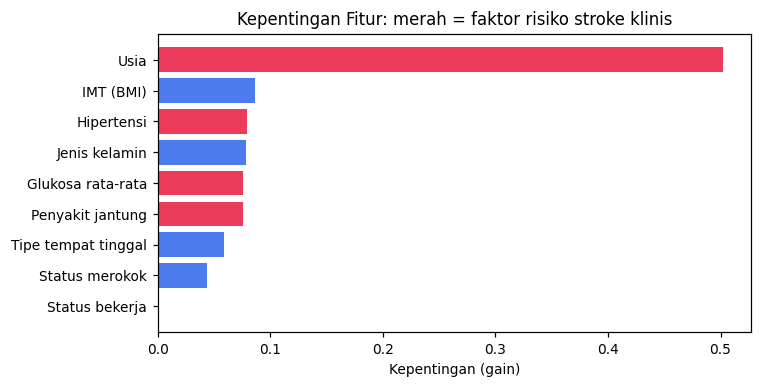

In [21]:
fig, ax = plt.subplots(figsize=(7, 3.6))
d = imp.sort_values("kepentingan")
cols = ["#eb3b5a" if f in ("age","avg_glucose_level","hypertension","heart_disease")
        else "#4b7bec" for f in d.fitur]
ax.barh(d.nama, d.kepentingan, color=cols)
ax.set_xlabel("Kepentingan (gain)")
ax.set_title("Kepentingan Fitur: merah = faktor risiko stroke klinis")
plt.tight_layout(); plt.show()

---
## 11. Menyimpan Artefak Model

Artefak menyimpan model **beserta** metadata inferensi, sehingga server
dijamin memakai urutan fitur dan ambang yang sama dengan saat pelatihan.
⚠️ Sel ini menulis ke folder terpisah (`artifacts_notebook/`) agar
**tidak menimpa** artefak produksi.

In [22]:
OUT_DIR = ROOT / "model" / "artifacts_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": model,
    "model_name": model_name,
    "encoding": encoding,
    "feature_order": FEATURE_ORDER,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "category_values": CATEGORY_VALUES,
    "threshold": threshold,
    "high_threshold": high_threshold,
}
joblib.dump(artifact, OUT_DIR / "stroke_risk_model.joblib")

metrics = {
    "model_name": model_name,
    "best_params": {k: (v if isinstance(v, (int, float, str)) or v is None else str(v))
                    for k, v in search.best_params_.items()},
    "cv_average_precision": float(search.best_score_),
    "threshold": threshold,
    "high_threshold": high_threshold,
    "target_recall": TARGET_RECALL,
    "test_auc": float(roc_auc_score(y_test, proba_test)),
    "test_average_precision": float(average_precision_score(y_test, proba_test)),
    "test_precision": float(precision_score(y_test, y_pred)),
    "test_recall": float(recall_score(y_test, y_pred)),
    "test_f1": float(f1_score(y_test, y_pred)),
    "test_confusion_matrix": cm.tolist(),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "positive_rate": float(y.mean()),
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

size_kb = (OUT_DIR / "stroke_risk_model.joblib").stat().st_size / 1024
print(f"Artefak tersimpan: {OUT_DIR.name}/stroke_risk_model.joblib  ({size_kb:.0f} KB)\n")
print("ISI ARTEFAK")
for k, v in artifact.items():
    ket = type(v).__name__ if k == "model" else v
    print(f"  {k:22s}: {ket}")

# Cek label risiko yang bakal tampil di aplikasi
lvl = np.where(proba_test >= high_threshold, "tinggi",
      np.where(proba_test >= threshold, "sedang", "rendah"))
print()
print("LABEL RISIKO DI APLIKASI (dari dua ambang tadi)")
for L in ["tinggi", "sedang", "rendah"]:
    m = lvl == L
    print(f"  {L:7s}: {m.sum():5d} orang ({100*m.mean():5.1f}%)  penderita di dalamnya: {int(y_test[m].sum())}")
print()
print("Dua ambang ini WAJIB dipisah. Kalau batas 'sedang' dihitung dari")
print("ambang deteksi (misal threshold x 0.5), begitu ambang deteksi turun")
print("ke 0,04 tidak ada satu orang pun yang dapat label 'rendah'.")


Artefak tersimpan: artifacts_notebook/stroke_risk_model.joblib  (146 KB)

ISI ARTEFAK
  model                 : XGBClassifier
  model_name            : XGBClassifier
  encoding              : ordinal_codes
  feature_order         : ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'is_working', 'gender', 'residence_type', 'smoking_status']
  numeric_features      : ['age', 'avg_glucose_level', 'bmi']
  binary_features       : ['hypertension', 'heart_disease', 'is_working']
  categorical_features  : ['gender', 'residence_type', 'smoking_status']
  category_values       : {'gender': ['Male', 'Female', 'Other'], 'residence_type': ['Urban', 'Rural'], 'smoking_status': ['formerly smoked', 'never smoked', 'smokes', 'Unknown']}
  threshold             : 0.041999999999999926
  high_threshold        : 0.705

LABEL RISIKO DI APLIKASI (dari dua ambang tadi)
  tinggi :   180 orang ( 11.7%)  penderita di dalamnya: 37
  sedang :   798 orang ( 52.1%)  penderita di dalamnya: 36
  re

---
## 12. Verifikasi terhadap Model Produksi

Ini penting kalau penguji bertanya apakah notebook sesuai dengan yang
benar-benar berjalan di server.

In [23]:
prod = ROOT / "model" / "artifacts" / "metrics.json"
if prod.exists():
    p = json.loads(prod.read_text())
    banding = [
        ("Model terpilih",      p["model_name"],                metrics["model_name"]),
        ("AP validasi silang",  f'{p["cv_average_precision"]:.4f}', f'{metrics["cv_average_precision"]:.4f}'),
        ("Ambang keputusan",    f'{p["threshold"]:.3f}',        f'{metrics["threshold"]:.3f}'),
        ("ROC-AUC uji",         f'{p["test_auc"]:.4f}',         f'{metrics["test_auc"]:.4f}'),
        ("Recall uji",          f'{p["test_recall"]:.4f}',      f'{metrics["test_recall"]:.4f}'),
    ]
    print(f"{'':22s} {'PRODUKSI':>26s} {'NOTEBOOK':>26s}   status")
    print("-" * 88)
    for nama, a, b in banding:
        print(f"{nama:22s} {a:>26s} {b:>26s}   {'COCOK' if str(a)==str(b) else 'BEDA'}")
else:
    print("metrics.json produksi tidak ditemukan: lewati verifikasi.")

                                         PRODUKSI                   NOTEBOOK   status
----------------------------------------------------------------------------------------
Model terpilih                      XGBClassifier              XGBClassifier   COCOK
AP validasi silang                         0.2313                     0.2313   COCOK
Ambang keputusan                            0.042                      0.042   COCOK
ROC-AUC uji                                0.8230                     0.8230   COCOK
Recall uji                                 0.9733                     0.9733   COCOK


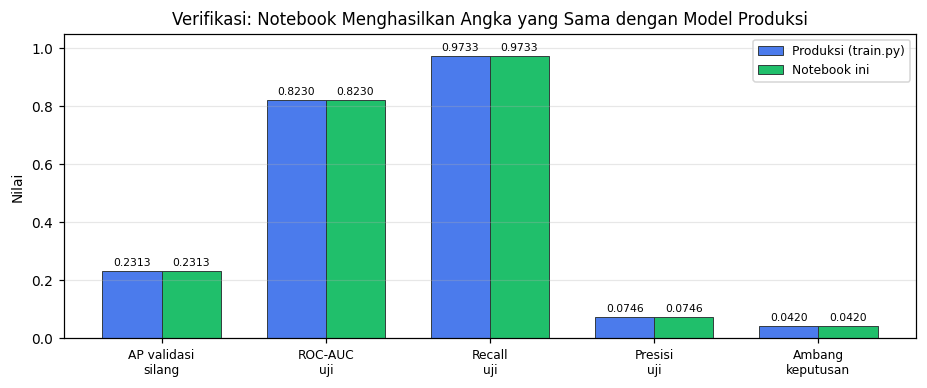

5 dari 5 metrik cocok persis.


In [24]:
if prod.exists():
    p = json.loads(prod.read_text())
    nm = ["AP validasi\nsilang", "ROC-AUC\nuji", "Recall\nuji", "Presisi\nuji", "Ambang\nkeputusan"]
    kunci = ["cv_average_precision", "test_auc", "test_recall", "test_precision", "threshold"]
    vp = [p[k] for k in kunci]; vn = [metrics[k] for k in kunci]

    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    xp = np.arange(len(nm)); w = 0.36
    b1 = ax.bar(xp - w/2, vp, w, label="Produksi (train.py)", color="#4b7bec",
                edgecolor="#2d3436", linewidth=.6)
    b2 = ax.bar(xp + w/2, vn, w, label="Notebook ini", color="#20bf6b",
                edgecolor="#2d3436", linewidth=.6)
    ax.bar_label(b1, fmt="%.4f", fontsize=7, padding=2)
    ax.bar_label(b2, fmt="%.4f", fontsize=7, padding=2)
    ax.set_xticks(xp, nm, fontsize=8); ax.set_ylim(0, 1.05)
    ax.set_ylabel("Nilai")
    ax.set_title("Verifikasi: Notebook Menghasilkan Angka yang Sama dengan Model Produksi")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.show()

    cocok = sum(1 for a, b in zip(vp, vn) if abs(a - b) < 1e-9)
    print(f"{cocok} dari {len(vp)} metrik cocok persis.")
else:
    print("metrics.json produksi tidak ditemukan.")

---
## Ringkasan

| Tahap | Hasil |
|---|---|
| Dataset | 5.110 baris, 9 fitur, 4,87% kasus stroke (rasio 1:19,56) |
| Penanganan ketimpangan | `scale_pos_weight = 19,56` pada fungsi loss |
| Metrik utama | Average precision, bukan akurasi |
| Penyetelan | RandomizedSearchCV 40 kombinasi, StratifiedKFold 5 lipatan |
| Model terpilih | XGBClassifier, AP validasi silang 0,2313 |
| Ambang deteksi | 0,042 (target recall 0,98 pada prediksi out-of-fold) |
| Ambang risiko tinggi | 0,705 (titik F1 terbaik) |
| **Recall data uji** | **0,973 (73 dari 75 penderita terdeteksi)** |
| ROC-AUC data uji | 0,823 |
| Presisi data uji | 0,075 |

Angka di atas identik dengan `model/artifacts/metrics.json`, yaitu model yang
berjalan di server produksi. Verifikasinya ada pada bagian 12.